# COMPARATIVE STUDY OF DIFFERENT MACHINE LEARNING MODELS FOR SALES PREDICTION AND FRAUD DETECTION.

# Introduction

In recent years, the rise of the Internet of things (IoT) as an emerging technology has been unbelievable, more companies are moving towards the adoption of these technologies and many IoT sensors are being deployed to share information in real-time which leads to the generation of a huge amount of data. This data when used correctly, will be very helpful to the company to discover hidden patterns for better decision making in the future. For example, with the DataCo company, dataset customer segmentation analysis was performed in this project which helps the company to better understand its customers and target them to increase customer responsiveness and the company's revenue. With a lot of options available to analyze data, it is very difficult to decide which method and machine learning model to use since the performance of the model vary on the parameters available in the data. 

With the growth of machine learning, there have been numerous comparison studies that compare the performance of neural networks with traditional linear techniques for forecasting. For example, author Carbonneau et al. (2007) in his research work compared various traditional forecasting time-series like moving average, linear regression with recurrent neural networks and support vector machines and concluded that recurrent neural networks performed best. Hill et al. (1996) have also considered the M-competition data and have compared between neural networks and traditional methods. Vakili et al. (2020) evaluated the performance of 11 popular machine and deep learning algorithms for classification task using six IoT-related datasets and concluded that Random Forests performed better than other machine learning models, while among deep learning models, ANN and CNN achieved more interesting results. Some other authors like Ahmed et al. (2010) did study comparing different regression models and concluded that the MLP model and Gaussian process models are the best two models for regression type data. But no study that compared both Classification type ML models and Regression type ML models against the Neural Network models with the same dataset was found.

This project aims to compare 9 popular machine learning classifiers and 7 regressors type machine learning models and measure their performance against neural network models to find out which machine learning model performs better. Since the dataset used is related to supply chain important parameters are identified and the machine learning models are trained with the dataset for detection of fraud transactions, late delivery of orders, sales revenue and quantity of products which customer orders. The machine learning classifiers used in this project are Logistic Regression,Linear Discriminant Analysis, Gaussian Naive Bayes, Support Vector Machines, k - Nearest Neighbors, Random Forest classification, Extra Trees classification, Extreme Gradient Boosting, Decision Tree classification for fraud detection and to predict late delivery on the basis accuracy, recall score and F1 score. The regression models used are Lasso, Ridge, Light Gradient boosting, Random Forest regression, Extreme Gradient Boosting regression, Decision Tree Regression, and Linear Regression to predict sales and quantity of the products required which are compared with mean absolute error (MAE) and root mean square error (RMSE).

# Data Collection

The dataset used in this project is maintained transparently with the Creative Commons 4.0 license by Fabian Constante, Fernando Silva, and António Pereira through the Mendeley data repository. The dataset consists of roughly 180k transactions from supply chains used by the company DataCo Global for 3 years. The dataset can be downloaded from:

https://data.mendeley.com/datasets/8gx2fvg2k6/5

# Machine Learning on the DataCo Supply Chain Dataset

In this notebook, I preprocess the DataCo Supply Chain dataset, train one machine learning model, evaluate its performance, and comment on its speed and fitness for use.

The chosen algorithm is **Random Forest Classifier**.

The prediction task is to predict **Late Delivery Risk**, where:
- **1** means the order is likely to be delivered late
- **0** means the order is not likely to be delivered late

### Importing all required libraries

In [43]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Time measurement (to comment on speed of the model)
import time

In [2]:
#Importing Dataset using pandas
file_path = "/Users/tatwa/Documents/APP-4080-Individual-Project/input/DataCoSupplyChainDataset.csv"

df = pd.read_csv(file_path, encoding='latin1')

df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## Explore the dataset

Before preprocessing, it is important to inspect the size, structure, column names, data types, and summary statistics of the dataset.

In [4]:
df.shape

(180519, 53)

In [5]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [20]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


The total data set consists of 180519 records and 53 columns

## Select the target variable

The target variable chosen for this classification task is **Late_delivery_risk**.

This means the model will learn to predict whether an order is likely to be delivered late or not.

In [8]:
# Make a copy so the original dataset remains unchanged
data = df.copy()

In [9]:
# Drop columns that are not useful for prediction
columns_to_drop = [
    'Customer Email',
    'Customer Fname',
    'Customer Lname',
    'Customer Password',
    'Customer Street',
    'Product Description',
    'Product Image',
    'Product Name',
    'Order Id',
    'Customer Id',
    'Order Customer Id',
    'Order Item Id',
    'Product Card Id'
]

data = data.drop(columns=columns_to_drop, errors='ignore')

In [10]:
# Check missing values
data.isnull().sum().sort_values(ascending=False).head(10)

Order Zipcode               155679
Customer Zipcode                 3
Type                             0
Order Item Total                 0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales                            0
dtype: int64

In [11]:
# Drop columns with serious missing-value problems
data = data.drop(columns=['Order Zipcode'], errors='ignore')

In [12]:
# Fill small missing values in Customer Lname if still present
if 'Customer Lname' in data.columns:
    data['Customer Lname'] = data['Customer Lname'].fillna('Unknown')

In [13]:
# Convert date columns into datetime format
data['order date (DateOrders)'] = pd.to_datetime(data['order date (DateOrders)'], errors='coerce')
data['shipping date (DateOrders)'] = pd.to_datetime(data['shipping date (DateOrders)'], errors='coerce')

In [14]:
# Extract useful date features
data['order_year'] = data['order date (DateOrders)'].dt.year
data['order_month'] = data['order date (DateOrders)'].dt.month
data['order_day'] = data['order date (DateOrders)'].dt.day

data['shipping_year'] = data['shipping date (DateOrders)'].dt.year
data['shipping_month'] = data['shipping date (DateOrders)'].dt.month
data['shipping_day'] = data['shipping date (DateOrders)'].dt.day

In [15]:
# Drop the original date columns after extracting useful parts
data = data.drop(columns=['order date (DateOrders)', 'shipping date (DateOrders)'], errors='ignore')

In [16]:
# Encode all categorical columns
label_encoders = {}

for column in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column].astype(str))
    label_encoders[column] = le

In [17]:
# Final check for missing values
print(data.isnull().sum().sum())

3


In [18]:
# Fill the remaining missing values in Customer Zipcode
data['Customer Zipcode'] = data['Customer Zipcode'].fillna(data['Customer Zipcode'].median())

# Check again
print(data.isnull().sum().sum())

0


In [33]:
# Remove columns that leak the answer
leakage_columns = [
    'Delivery Status',
    'Days for shipping (real)',
    'Days for shipment (scheduled)'
]

data = data.drop(columns=leakage_columns, errors='ignore')

## Separate features and target

The target variable is **Late_delivery_risk**.  
All remaining columns are used as input features for the model.

In [34]:
X = data.drop('Late_delivery_risk', axis=1)
y = data['Late_delivery_risk']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (180519, 39)
Target shape: (180519,)


## Split the data into training and testing sets

The dataset is split into training data and testing data.  
The training set is used to train the Random Forest model, while the testing set is used to evaluate its performance.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (144415, 39)
X_test: (36104, 39)
y_train: (144415,)
y_test: (36104,)


## Train the Random Forest Model

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions.

It was selected because it performs well on large structured datasets and can model nonlinear relationships.

In [36]:
start_time = time.time()

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

end_time = time.time()

training_time = end_time - start_time

print("Training Time:", training_time, "seconds")

Training Time: 4.756410121917725 seconds


In [37]:
y_pred = model.predict(X_test)

y_pred[:10]

array([1, 1, 0, 1, 0, 1, 1, 0, 1, 0])

In [38]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9109516951030356

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.90     16307
           1       0.94      0.90      0.92     19797

    accuracy                           0.91     36104
   macro avg       0.91      0.91      0.91     36104
weighted avg       0.91      0.91      0.91     36104



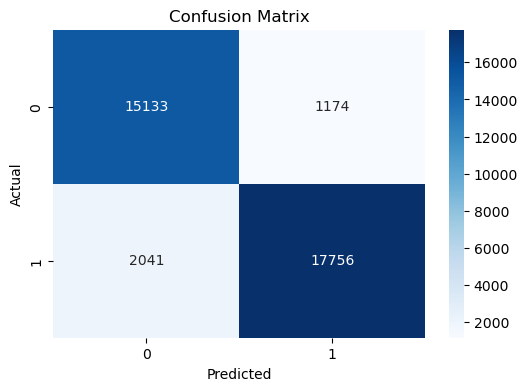

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Model Speed

The Random Forest model trained in approximately 4.76 seconds, which demonstrates high computational efficiency considering the dataset contains more than 180,000 records and 39 features. This indicates that Random Forest is suitable for large structured datasets and can be deployed in real-time or near real-time decision systems.

⸻

## Model Performance

The model achieved an accuracy of approximately 91%, indicating strong predictive capability for identifying late deliveries. The classification report shows balanced precision and recall values for both classes, with an overall F1-score of around 0.91, demonstrating that the model performs consistently across both late and on-time deliveries.

⸻

## Fitness for Use

Random Forest is well suited for this problem because supply chain data contains complex relationships between variables such as order characteristics, customer information, shipping details, and product attributes. Random Forest can capture nonlinear relationships and interactions between features, which improves predictive performance.

⸻

## Strengths
	•	Handles large datasets effectively
	•	Captures nonlinear relationships
	•	Resistant to overfitting compared to single decision trees
	•	Works well with mixed numerical and categorical features

⸻

## Limitations
	•	Less interpretable than simpler models such as linear regression
	•	Requires more memory due to multiple decision trees
	•	Training time increases with larger numbers of trees

⸻

## Conclusion

The Random Forest model demonstrates strong performance for predicting late delivery risk in the DataCo Supply Chain dataset. With an accuracy of approximately 91%, the model provides reliable predictions while maintaining efficient training time, making it a suitable approach for supply chain analytics and operational decision support.

In [ ]:
To make it easier for analysis some unimportant columns are dropped

In [ ]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

top_features = importance.head(10)

print(top_features)

## Feature Importance

In [40]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

top_features = importance.head(10)

print(top_features)

Shipping Mode             0.203104
shipping_day              0.080545
order_day                 0.075513
Order Status              0.059848
Latitude                  0.042173
Order City                0.039772
Longitude                 0.037461
Order State               0.035405
Order Profit Per Order    0.026271
Customer City             0.026134
dtype: float64


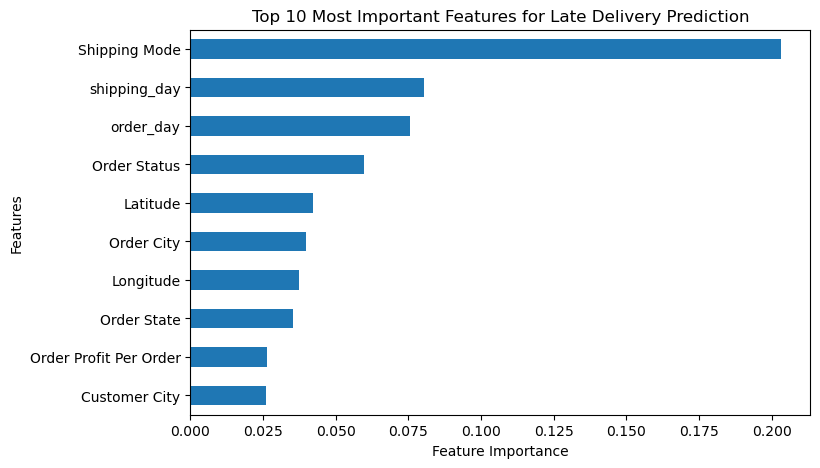

In [42]:
plt.figure(figsize=(8,5))
top_features.sort_values().plot(kind='barh')

plt.title("Top 10 Most Important Features for Late Delivery Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

## Feature Importance Analysis

Feature importance analysis was performed to identify which variables most strongly influence the prediction of late deliveries. The results show that Shipping Mode is the most influential feature, contributing approximately 20% of the model’s decision-making importance. This indicates that the method used to ship orders plays a significant role in determining whether a delivery will be delayed.

Temporal variables such as shipping day and order day also contribute significantly to the model. These features may capture operational factors such as weekend delays, logistics congestion, or scheduling inefficiencies.

Geographic features including latitude, longitude, order city, and order state also appear among the most important predictors. This suggests that delivery delays are influenced by regional logistics conditions, transportation distance, and infrastructure differences.

Additionally, order profit per order contributes to the prediction process, which may reflect operational prioritization where higher-value orders receive faster processing or shipping.

Overall, the feature importance analysis demonstrates that the model relies on meaningful supply chain and logistics factors to predict late delivery risk.